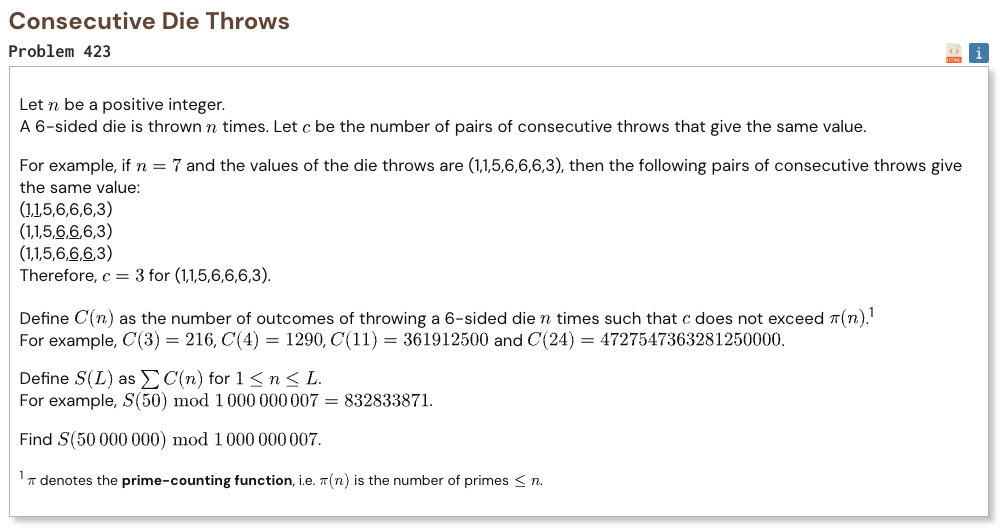

## Initial approach

-   choose which gaps between throws have the same value as the previous throw
-   the first throw has 6 choices and every changed throw has 5 choices
-   use a prime sieve to know how many equal neighbouring throws are allowed for each length
-   keep the current valid outcome count instead of calculating it again from the beginning
-   update this count differently when the next number is prime and when it is not prime
-   keep one extra boundary value that lets us perform each update in constant time
-   use `array` to store modular inverses with much less memory than a normal Python list
-   add every valid outcome count and keep the result modulo one billion and seven

In [1]:
%%time

from array import array

LIMIT = 50_000_000
MOD = 1_000_000_007

is_prime = bytearray(b"\x01") * (LIMIT + 1)
is_prime[0] = 0
is_prime[1] = 0

p = 2

while p * p <= LIMIT:
    if is_prime[p]:
        start = p * p
        is_prime[start:LIMIT + 1:p] = b"\x00" * (
            (LIMIT - start) // p + 1
        )
    p += 1

inverse = array("I", [0]) * (LIMIT + 1)
inverse[1] = 1

for i in range(2, LIMIT + 1):
    inverse[i] = (
        MOD
        - (MOD // i) * inverse[MOD % i] % MOD
    )

current = 6
boundary = 1
prime_count = 0
result = 6

for n in range(1, LIMIT):
    if is_prime[n + 1]:
        extra = (
            6
            * boundary
            % MOD
            * (n - 1 - prime_count)
            % MOD
            * inverse[prime_count + 1]
            % MOD
        )

        current = (6 * current + extra) % MOD

        prime_count += 1

        boundary = (
            boundary
            * n
            % MOD
            * inverse[prime_count]
            % MOD
        )

    else:
        current = (
            6 * current
            - 6 * boundary
        ) % MOD

        boundary = (
            boundary
            * 5
            % MOD
            * n
            % MOD
            * inverse[n - prime_count]
            % MOD
        )

    result = (result + current) % MOD

print("Result:", result)

Result: 653972374
CPU times: user 24.3 s, sys: 98.8 ms, total: 24.4 s
Wall time: 24.5 s
